In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [3]:
df =  pd.read_csv("StudentPerformanceFactors.csv")
print("Shape:",df.shape)
df.head()

Shape: (6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [5]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [6]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [7]:
# make copy of original datasets 
df_copy = df.copy()

In [8]:
df.columns=(df.columns.str.strip().str.lower().str.replace(r'[^a-z0-9]+', '_', regex=True).str.strip("_"))

In [9]:
# drop duplicates

df = df.drop_duplicates().copy()

In [10]:
# clean text columns
text_cols = df.select_dtypes(include=['object', 'string']).columns

df[text_cols] = (
    df[text_cols]
    .astype('string')
    .apply(lambda s: s.str.strip())
    .replace({'': pd.NA, 'nan': pd.NA, 'None': pd.NA})
)

In [11]:
df.head()

,hours_studied,attendance,parental_involvement,access_to_resources,extracurricular_activities,sleep_hours,previous_scores,motivation_level,internet_access,tutoring_sessions,family_income,teacher_quality,school_type,peer_influence,physical_activity,learning_disabilities,parental_education_level,distance_from_home,gender,exam_score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [12]:
# convert numeric columns
numeric_cols = ['hours_studied', 'attendance', 'sleep_hours', 'previous_scores', 'tutoring_sessions', 'physical_activity','exam_score']

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [13]:
# fill numeric missing values with median
target_cols = ['hours_studied', 'attendance', 'sleep_hours', 'previous_scores', 'tutoring_sessions', 'physical_activity','exam_score']
df[target_cols] = df[target_cols].fillna(df[target_cols].median())


In [14]:
df.head()

,hours_studied,attendance,parental_involvement,access_to_resources,extracurricular_activities,sleep_hours,previous_scores,motivation_level,internet_access,tutoring_sessions,family_income,teacher_quality,school_type,peer_influence,physical_activity,learning_disabilities,parental_education_level,distance_from_home,gender,exam_score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [15]:
# fill categorical missing values with the mode

cat_cols = ['parental_involvement', 'access_to_resources', 'extracurricular_activities', 'motivation_level', 'internet_access','family_income','teacher_quality','school_type','peer_influence','learning_disabilities','parental_education_level','distance_from_home','gender']

df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])


In [16]:
print("\nMissing values after cleaning:")
display(df.isna().sum().sort_values(ascending=False).to_frame('missing_after_cleaning'))


Missing values after cleaning:


,missing_after_cleaning
hours_studied,0
attendance,0
parental_involvement,0
access_to_resources,0
extracurricular_activities,0
sleep_hours,0
previous_scores,0
motivation_level,0
internet_access,0
tutoring_sessions,0


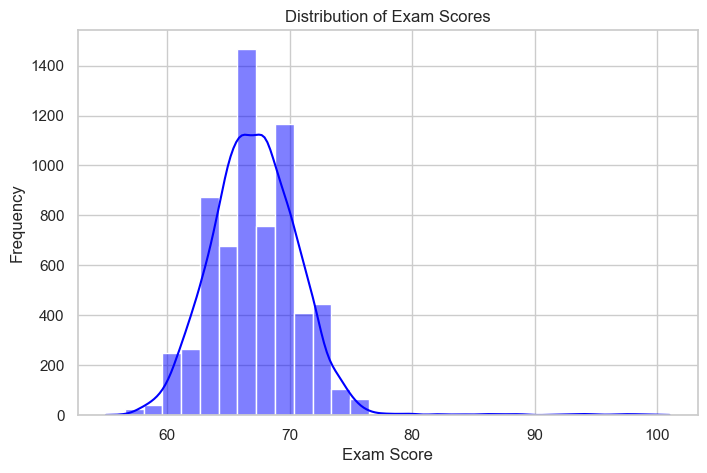

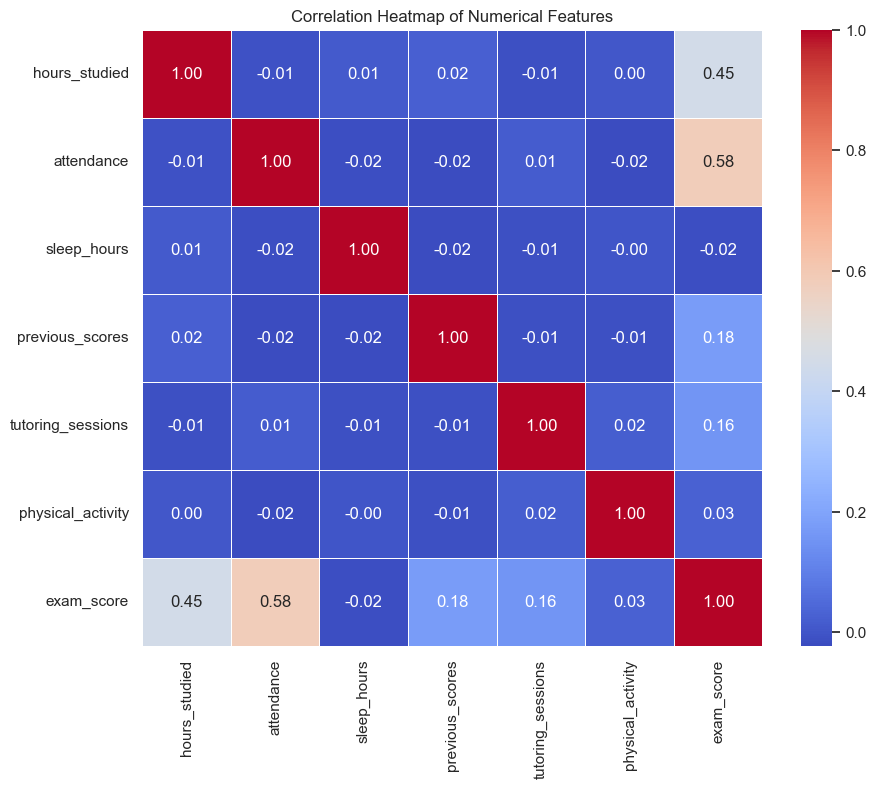

In [17]:
# --- CORRECTED FEATURE GROUPS ---
# Removed 'distance_from_home' from here
target = 'exam_score'
numerical_cols = [
    'hours_studied', 'attendance', 'sleep_hours', 'previous_scores', 
    'tutoring_sessions', 'physical_activity'
]

# Added 'distance_from_home' to here
categorical_cols = [
    'parental_involvement', 'access_to_resources', 'extracurricular_activities', 
    'motivation_level', 'internet_access', 'family_income', 'teacher_quality', 
    'school_type', 'peer_influence', 'learning_disabilities', 
    'parental_education_level', 'gender', 'distance_from_home'
]

# Set visual style
sns.set_theme(style="whitegrid")

# --- 1. TARGET VARIABLE DISTRIBUTION ---
plt.figure(figsize=(8, 5))
sns.histplot(df[target], kde=True, bins=30, color='blue')
plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.show()

# --- 2. CORRELATION HEATMAP (Numerical Features) ---
plt.figure(figsize=(10, 8))
corr_df = df[numerical_cols + [target]]
# Added numeric_only=True as a failsafe
sns.heatmap(corr_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [18]:
# Apply one-hot encoding to all categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df_encoded = df_encoded.astype(int)

print(f"Original dataframe shape: {df.shape}")
print(f"Encoded dataframe shape: {df_encoded.shape}")

df_encoded.head()

Original dataframe shape: (6607, 20)
Encoded dataframe shape: (6607, 28)


,hours_studied,attendance,sleep_hours,previous_scores,tutoring_sessions,physical_activity,exam_score,parental_involvement_Low,parental_involvement_Medium,access_to_resources_Low,access_to_resources_Medium,extracurricular_activities_Yes,motivation_level_Low,motivation_level_Medium,internet_access_Yes,family_income_Low,family_income_Medium,teacher_quality_Low,teacher_quality_Medium,school_type_Public,peer_influence_Neutral,peer_influence_Positive,learning_disabilities_Yes,parental_education_level_High School,parental_education_level_Postgraduate,gender_Male,distance_from_home_Moderate,distance_from_home_Near
0,23,84,7,73,0,3,67,1,0,0,0,0,1,0,1,1,0,0,1,1,0,1,0,1,0,1,0,1
1,19,64,8,59,2,4,61,1,0,0,1,0,1,0,1,0,1,0,1,1,0,0,0,0,0,0,1,0
2,24,98,7,91,2,4,74,0,1,0,1,1,0,1,1,0,1,0,1,1,1,0,0,0,1,1,0,1
3,29,89,8,98,1,4,71,1,0,0,1,1,0,1,1,0,1,0,1,1,0,0,0,1,0,1,1,0
4,19,92,6,65,3,4,70,0,1,0,1,1,0,1,1,0,1,0,0,1,1,0,0,0,0,0,0,1


In [19]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('exam_score', axis=1)
y = df_encoded['exam_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape (X_train): {X_train.shape}")
print(f"Testing features shape (X_test): {X_test.shape}")
print(f"Training target shape (y_train): {y_train.shape}")
print(f"Testing target shape (y_test): {y_test.shape}")

Training features shape (X_train): (5285, 27)
Testing features shape (X_test): (1322, 27)
Training target shape (y_train): (5285,)
Testing target shape (y_test): (1322,)


In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Scale the numerical data
# Critical: Only fit the scaler on the TRAINING data to prevent data leakage, then transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Initialize the models
models = {
    "Ridge Regression": Ridge(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42)
}

# 3. Train and Evaluate each model
print("--- Model Performance Comparison ---")
for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions on the unseen test set
    predictions = model.predict(X_test_scaled)
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    print(f"\n{name}:")
    print(f"  RMSE: {rmse:.2f} (Lower is better)")
    print(f"  R-squared (R2): {r2:.4f} (Closer to 1.0 is better)")

--- Model Performance Comparison ---

Ridge Regression:
  RMSE: 1.80 (Lower is better)
  R-squared (R2): 0.7697 (Closer to 1.0 is better)

Random Forest:
  RMSE: 2.23 (Lower is better)
  R-squared (R2): 0.6492 (Closer to 1.0 is better)

XGBoost:
  RMSE: 2.15 (Lower is better)
  R-squared (R2): 0.6736 (Closer to 1.0 is better)


C:\Users\Pankaj\AppData\Local\Temp\ipykernel_3660\2259221035.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


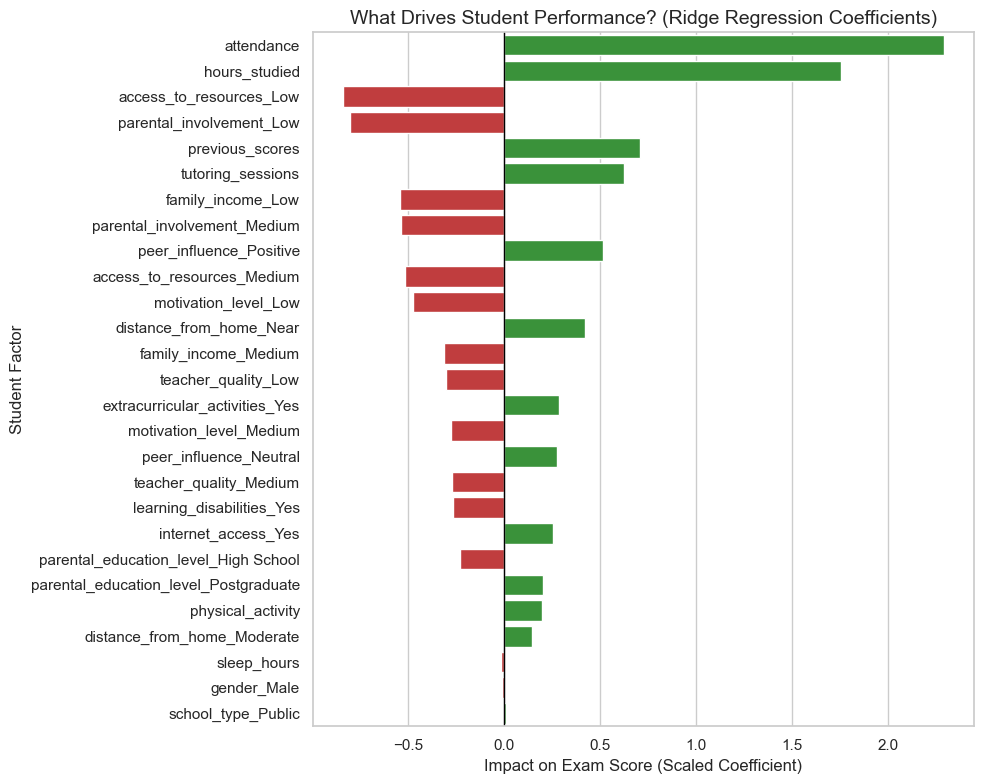

--- TOP 5 DRIVERS OF EXAM SCORES ---
                 Feature  Importance
              attendance    2.289966
           hours_studied    1.756533
 access_to_resources_Low   -0.838668
parental_involvement_Low   -0.804324
         previous_scores    0.705767


In [21]:

# 1. Retrieve the trained Ridge model from your models dictionary
best_model = models["Ridge Regression"]

# 2. Extract the coefficients (the "weight" the model gave to each feature)
coefficients = best_model.coef_

# 3. Create a DataFrame to map the feature names to their coefficients
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': coefficients
})

# 4. Sort by the absolute importance to see the biggest drivers at the top
feature_importance['Abs_Importance'] = feature_importance['Importance'].abs()
feature_importance = feature_importance.sort_values(by='Abs_Importance', ascending=False)

# 5. Plot the insights
plt.figure(figsize=(10, 8))
# Differentiate between positive and negative impact using colors
colors = ['#2ca02c' if val > 0 else '#d62728' for val in feature_importance['Importance']]

sns.barplot(
    data=feature_importance, 
    x='Importance', 
    y='Feature', 
    palette=colors
)

plt.title("What Drives Student Performance? (Ridge Regression Coefficients)", fontsize=14)
plt.xlabel("Impact on Exam Score (Scaled Coefficient)", fontsize=12)
plt.ylabel("Student Factor", fontsize=12)
plt.axvline(0, color='black', linewidth=1) # Draw a neutral zero-line
plt.tight_layout()
plt.show()

# 6. Print the top 5 driving factors
print("--- TOP 5 DRIVERS OF EXAM SCORES ---")
print(feature_importance[['Feature', 'Importance']].head(5).to_string(index=False))